# GraphGuard — Notebook 1: Data Collection & Preprocessing

**Project:** TempoStruct-GAN — Adversarial, Time-Aware, Subgraph-Realism-Checked Oversampling for Fraud Detection  
**Dataset:** Elliptic Bitcoin Dataset (203,769 nodes × 166 features, 49 time steps)  

This notebook covers:
- Phase 0: Environment setup (installs PyG, mounts Google Drive)
- Phase 1: Full preprocessing pipeline
- EDA visualisations for Review-1/2 slides

**Run on**: Google Colab (recommended — free GPU)

---

## 🔧 Phase 0 — Environment Setup

Run this cell first. It:
1. Mounts your Google Drive (saves data persistently across sessions)
2. Installs `torch-geometric` and dependencies
3. Copies the GraphGuard source files from Drive if they exist

In [ ]:
# ── Local environment setup ─────────────────────────────────────────────────
import os, sys, warnings
warnings.filterwarnings('ignore')

# Local project root — all data and models saved here
BASE_DIR = r'E:\GraphGuard\project-1\graphguard'

for d in ['data/raw', 'data/processed', 'models', 'results']:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

RAW_DIR     = os.path.join(BASE_DIR, 'data', 'raw')
PROC_DIR    = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

print(f'Base dir      : {BASE_DIR}')
print(f'Raw data dir  : {RAW_DIR}')
print(f'Processed dir : {PROC_DIR}')
print(f'Models dir    : {MODELS_DIR}')
print(f'Results dir   : {RESULTS_DIR}')
print()
print('NOTE: Running locally (CPU). No Colab/Drive needed.')


Base dir      : C:\Users\HP\Desktop\project1\graphguard
Raw data dir  : C:\Users\HP\Desktop\project1\graphguard\data\raw
Processed dir : C:\Users\HP\Desktop\project1\graphguard\data\processed
Models dir    : C:\Users\HP\Desktop\project1\graphguard\models
Results dir   : C:\Users\HP\Desktop\project1\graphguard\results

NOTE: Running locally (CPU). No Colab/Drive needed.


In [8]:
# PyG and dependencies already installed locally — nothing to do here.
import torch
import torch_geometric
print(f'PyTorch          : {torch.__version__}')
print(f'PyTorch Geometric: {torch_geometric.__version__}')
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device           : {DEVICE}')


PyTorch          : 2.11.0+cpu
PyTorch Geometric: 2.8.0.post1
Device           : cpu


In [9]:
# ── Core imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
print(f'NetworkX : {nx.__version__}')

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
FIGSIZE = (12, 5)

PyTorch  : 2.11.0+cpu
Device   : cpu
NetworkX : 3.6.1


---
## Phase 1.1 — Dataset Acquisition

Run the cell below to:
1. Install Kaggle
2. Upload your `kaggle.json` API token
3. Download and extract the Elliptic Bitcoin Dataset automatically
4. Copy CSVs to the expected `RAW_DIR`

**Get your `kaggle.json`**: Kaggle → Account → API → Create New Token

> If you already uploaded the CSVs manually to Drive, skip to the next cell.

In [10]:
# ── Dataset acquisition (local) ──────────────────────────────────────────────
# Place the three Elliptic CSV files in the RAW_DIR folder:
#   elliptic_txs_features.csv
#   elliptic_txs_classes.csv
#   elliptic_txs_edgelist.csv
#
# Download from: https://www.kaggle.com/datasets/ellipticco/elliptic-data-set
# Then copy/paste them into:
#   C:\Users\HP\Desktop\project1\graphguard\\data\\raw\\

import os
required = [
    'elliptic_txs_features.csv',
    'elliptic_txs_classes.csv',
    'elliptic_txs_edgelist.csv',
]
missing = [f for f in required if not os.path.exists(os.path.join(RAW_DIR, f))]
if missing:
    print('MISSING FILES — copy these to RAW_DIR before continuing:')
    for m in missing:
        print(f'  {os.path.join(RAW_DIR, m)}')
    raise FileNotFoundError('Missing CSV files. See instructions above.')
else:
    print('All 3 CSV files found in RAW_DIR.')


All 3 CSV files found in RAW_DIR.


In [11]:
# ── Load raw CSVs ─────────────────────────────────────────────────────────────
import pandas as pd

print('Loading CSVs...')

# ── IMPORTANT: features.csv has NO header row ──────────────────────────────
# Column layout: col0=txId, col1=timestep, col2..col167 = 166 features
# Loading without header=None would treat the first DATA row as column names.
feat_cols = ['txId', 'timestep'] + [f'f{i}' for i in range(1, 167)]
df_feat = pd.read_csv(
    os.path.join(RAW_DIR, 'elliptic_txs_features.csv'),
    header=None,
    names=feat_cols
)

# ── classes.csv and edgelist.csv both have headers ──────────────────────────
df_class = pd.read_csv(os.path.join(RAW_DIR, 'elliptic_txs_classes.csv'))
df_edges = pd.read_csv(os.path.join(RAW_DIR, 'elliptic_txs_edgelist.csv'))

print(f'Features   : {df_feat.shape}  (expect 203769 rows x 168 cols)')
print(f'Classes    : {df_class.shape}  (expect 203769 rows x 2 cols)')
print(f'Edges      : {df_edges.shape}  (expect ~234355 rows x 2 cols)')

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert df_feat.shape[1] == 168, (
    f'Expected 168 cols (txId + timestep + 166 features), got {df_feat.shape[1]}'
)
assert 'txId'     in df_feat.columns, 'txId column missing from features'
assert 'timestep' in df_feat.columns, 'timestep column missing from features'

print('\nMissing values:')
print(f'  Features : {df_feat.isnull().sum().sum()}')
print(f'  Classes  : {df_class.isnull().sum().sum()}')
print(f'  Edges    : {df_edges.isnull().sum().sum()}')

# ── Class distribution ────────────────────────────────────────────────────────
print('\nClass distribution (raw):')
print(df_class['class'].value_counts())

print('\n  1         = Illicit')
print('  2         = Licit')
print('  unknown   = Unlabelled (kept in graph, masked from loss)')

# ── Dataset summary ───────────────────────────────────────────────────────────
print('\n================ SUMMARY ================')
print(f'Feature records : {len(df_feat):,}')
print(f'Class records   : {len(df_class):,}')
print(f'Edges           : {len(df_edges):,}')
print('\nPhase 1.1 -- Dataset Acquisition COMPLETE.')

display(df_feat.head(3))
display(df_class.head(3))
display(df_edges.head(3))

Loading CSVs...
Features   : (203769, 168)  (expect 203769 rows x 168 cols)
Classes    : (203769, 2)  (expect 203769 rows x 2 cols)
Edges      : (234355, 2)  (expect ~234355 rows x 2 cols)

Missing values:
  Features : 203769
  Classes  : 0
  Edges    : 0

Class distribution (raw):
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

  1         = Illicit
  2         = Licit
  unknown   = Unlabelled (kept in graph, masked from loss)

================ SUMMARY ================
Feature records : 203,769
Class records   : 203,769
Edges           : 234,355

Phase 1.1 -- Dataset Acquisition COMPLETE.


,txId,timestep,f1,f2,f3,f4,f5,f6,f7,f8,...,f157,f158,f159,f160,f161,f162,f163,f164,f165,f166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,NaN


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870


---
## 🧹 Phase 1.2 — Cleaning & Structuring

In [12]:
# ── Step 1: Map txId → contiguous integer node IDs ──────────────────────────
all_nodes = df_feat['txId'].values
node_id_map = {txid: i for i, txid in enumerate(all_nodes)}
N = len(all_nodes)
print(f'Total nodes: {N:,}')

# Save lookup table
lookup_df = pd.DataFrame({'txId': all_nodes, 'node_id': range(N)})
lookup_df.to_csv(os.path.join(PROC_DIR, 'node_id_lookup.csv'), index=False)
print('✅ Node ID lookup saved')

# ── Step 2: Recode labels ────────────────────────────────────────────────────
# Merge features with classes on txId
df_merged = df_feat.merge(df_class, on='txId', how='left')

def recode_label(x):
    if x == '1' or x == 1:
        return 1   # illicit
    elif x == '2' or x == 2:
        return 0   # licit
    else:
        return -1  # unknown (kept in graph, masked in loss)

df_merged['label'] = df_merged['class'].apply(recode_label)

print('\nRecoded label distribution:')
label_counts = df_merged['label'].value_counts().sort_index()
label_names = {-1: 'Unknown', 0: 'Licit', 1: 'Illicit'}
for k, v in label_counts.items():
    pct = v / N * 100
    print(f'  {label_names[k]:8s} ({k:2d}): {v:8,}  ({pct:.1f}%)')

Total nodes: 203,769
✅ Node ID lookup saved

Recoded label distribution:
  Unknown  (-1):  157,205  (77.1%)
  Licit    ( 0):   42,019  (20.6%)
  Illicit  ( 1):    4,545  (2.2%)


In [13]:
# ── Step 3: Verify timesteps (1-49) ─────────────────────────────────────────
timesteps = df_merged['timestep'].values
print(f'Timestep range: {timesteps.min()} → {timesteps.max()}')
print(f'Unique timesteps: {sorted(df_merged["timestep"].unique())}')

# ── Step 4: Build edge index using contiguous IDs ───────────────────────────
valid_mask = df_edges['txId1'].isin(node_id_map) & df_edges['txId2'].isin(node_id_map)
df_edges_valid = df_edges[valid_mask].copy()
print(f'\nTotal edges     : {len(df_edges):,}')
print(f'Valid edges     : {len(df_edges_valid):,}  ({len(df_edges_valid)/len(df_edges)*100:.1f}%)')

src_ids = df_edges_valid['txId1'].map(node_id_map).values
dst_ids = df_edges_valid['txId2'].map(node_id_map).values

# Build node → timestep array
ts_array = df_merged['timestep'].values  # indexed by node_id

# ── Step 5: Temporal edge validity check ────────────────────────────────────
src_ts = ts_array[src_ids]
dst_ts = ts_array[dst_ids]

violations = (src_ts > dst_ts).sum()
same_step  = (src_ts == dst_ts).sum()
forward    = (src_ts < dst_ts).sum()

print(f'\n⏱️  Temporal edge audit:')
print(f'   Forward  (src_t < dst_t): {forward:,}  ({forward/len(src_ids)*100:.1f}%)')
print(f'   Same step(src_t = dst_t): {same_step:,}  ({same_step/len(src_ids)*100:.1f}%)')
print(f'   Backward (src_t > dst_t): {violations:,}  ({violations/len(src_ids)*100:.1f}%)')

if violations > 0:
    print(f'\n⚠️  {violations:,} backward edges exist in raw data.')
    print('   These will be kept in the graph (information still valid),')
    print('   but the generator will NEVER create such edges (temporal constraint enforced).')
else:
    print('\n✅ No temporal violations in raw data — graph is causally clean.')

Timestep range: 1 → 49
Unique timesteps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Total edges     : 234,355
Valid edges     : 234,355  (100.0%)

⏱️  Temporal edge audit:
   Forward  (src_t < dst_t): 0  (0.0%)
   Same step(src_t = dst_t): 234,355  (100.0%)
   Backward (src_t > dst_t): 0  (0.0%)

✅ No temporal violations in raw data — graph is causally clean.


---
## 🔬 Phase 1.3 — Feature Engineering

In [14]:
# ── Per-timestep z-score normalisation ──────────────────────────────────────
# NOTE: We normalise PER TIMESTEP, not globally.
# Reason: feature distributions drift across time steps (Bitcoin network evolves).
# Global normalisation would leak temporal information into the 'local' features.
feature_cols = [f'f{i}' for i in range(1, 167)]
raw_features = df_merged[feature_cols].values.astype(np.float32)

normalised = np.zeros_like(raw_features)
for t in sorted(df_merged['timestep'].unique()):
    mask = (df_merged['timestep'] == t).values
    X_t = raw_features[mask]
    mean_t = X_t.mean(axis=0)
    std_t  = X_t.std(axis=0) + 1e-8  # avoid division by zero
    normalised[mask] = (X_t - mean_t) / std_t

print(f'✅ Per-timestep normalisation complete.')
print(f'   Feature matrix shape: {normalised.shape}')
print(f'   Global mean after norm: {normalised.mean():.4f}  (expect ≈ 0)')
print(f'   Global std  after norm: {normalised.std():.4f}  (≈ 1 per timestep)')

✅ Per-timestep normalisation complete.
   Feature matrix shape: (203769, 166)
   Global mean after norm: nan  (expect ≈ 0)
   Global std  after norm: nan  (≈ 1 per timestep)


In [15]:
# ── Structural feature computation via NetworkX ─────────────────────────────
# Features: in-degree, out-degree, local clustering coeff, ego-density,
#           neighbour label homophily (fraction of known-label neighbours that are illicit)

print('Building NetworkX graph for structural feature extraction...')
print('(This may take 2-4 minutes for the full graph)')

G_nx = nx.DiGraph()
G_nx.add_nodes_from(range(N))
G_nx.add_edges_from(zip(src_ids, dst_ids))

labels_arr = df_merged['label'].values  # -1/0/1

struct_feats = np.zeros((N, 4), dtype=np.float32)

print('Computing structural features...')
G_undirected = G_nx.to_undirected()

# In/out-degree from directed graph
in_degrees  = np.array([G_nx.in_degree(i)  for i in range(N)], dtype=np.float32)
out_degrees = np.array([G_nx.out_degree(i) for i in range(N)], dtype=np.float32)
degrees     = in_degrees + out_degrees

print('  ✓ Degrees computed')

# Local clustering coefficient (on undirected version)
clustering_dict = nx.clustering(G_undirected)
clustering_arr  = np.array([clustering_dict[i] for i in range(N)], dtype=np.float32)
print('  ✓ Clustering coefficients computed')

# Neighbour label homophily: fraction of neighbours with label == 1 (illicit)
# among those with known labels (0 or 1)
homophily = np.zeros(N, dtype=np.float32)
for i in range(N):
    nbrs = list(G_undirected.neighbors(i))
    if nbrs:
        nbr_labels = labels_arr[nbrs]
        known_nbrs = nbr_labels[nbr_labels != -1]
        if len(known_nbrs) > 0:
            homophily[i] = (known_nbrs == 1).sum() / len(known_nbrs)
print('  ✓ Neighbour homophily computed')

# Ego-graph density: edge density of the 1-hop ego subgraph
# To avoid O(N) ego-graph builds on large graph, use degree-based approximation:
# density ≈ actual_edges / max_possible_edges — we compute exactly for small-degree nodes
ego_density = np.zeros(N, dtype=np.float32)
for i in range(N):
    nbrs = list(G_undirected.neighbors(i))
    k = len(nbrs)
    if k >= 2:
        subg = G_undirected.subgraph(nbrs)
        n_edges = subg.number_of_edges()
        max_edges = k * (k - 1) / 2
        ego_density[i] = n_edges / max_edges if max_edges > 0 else 0.0
print('  ✓ Ego-graph densities computed')

# Stack into [N, 4] structural feature matrix
# Columns: [degree, clustering_coeff, homophily, ego_density]
struct_feats[:, 0] = degrees
struct_feats[:, 1] = clustering_arr
struct_feats[:, 2] = homophily
struct_feats[:, 3] = ego_density

print(f'\n✅ Structural features shape: {struct_feats.shape}')
print('   Columns: [degree, clustering_coeff, homophily, ego_density]')
print(f'   Degree range: {degrees.min():.0f} – {degrees.max():.0f}')
print(f'   Clustering range: {clustering_arr.min():.3f} – {clustering_arr.max():.3f}')
print(f'   Homophily range: {homophily.min():.3f} – {homophily.max():.3f}')

Building NetworkX graph for structural feature extraction...
(This may take 2-4 minutes for the full graph)
Computing structural features...
  ✓ Degrees computed
  ✓ Clustering coefficients computed
  ✓ Neighbour homophily computed
  ✓ Ego-graph densities computed

✅ Structural features shape: (203769, 4)
   Columns: [degree, clustering_coeff, homophily, ego_density]
   Degree range: 1 – 473
   Clustering range: 0.000 – 1.000
   Homophily range: 0.000 – 1.000


---
## ✂️ Phase 1.4 — Temporal Splits

**Standard Elliptic protocol (temporal, not random):**
- Train: time steps 1–29
- Validation: time steps 30–34  
- Test: time steps 35–49

⚠️ Unknown nodes (`label == -1`) are kept in the graph but masked out of loss computation.

In [16]:
# ── Temporal split masks ─────────────────────────────────────────────────────
TRAIN_TS_END = 29
VAL_TS_END   = 34
# Test: 35-49

train_mask = torch.tensor(ts_array <= TRAIN_TS_END,   dtype=torch.bool)
val_mask   = torch.tensor((ts_array > TRAIN_TS_END) & (ts_array <= VAL_TS_END), dtype=torch.bool)
test_mask  = torch.tensor(ts_array > VAL_TS_END,      dtype=torch.bool)

# Labelled-only masks (for loss computation — exclude unknowns)
labels_t    = torch.tensor(labels_arr, dtype=torch.long)
known_mask  = labels_t != -1

train_labelled_mask = train_mask & known_mask
val_labelled_mask   = val_mask   & known_mask
test_labelled_mask  = test_mask  & known_mask

print('Split summary:')
print(f'  Train     : {train_mask.sum():6,} nodes  (ts 1–{TRAIN_TS_END})')
print(f'  Val       : {val_mask.sum():6,} nodes  (ts {TRAIN_TS_END+1}–{VAL_TS_END})')
print(f'  Test      : {test_mask.sum():6,} nodes  (ts {VAL_TS_END+1}–49)')
print()
print(f'  Train (labelled): {train_labelled_mask.sum():6,} nodes')
print(f'  Val   (labelled): {val_labelled_mask.sum():6,} nodes')
print(f'  Test  (labelled): {test_labelled_mask.sum():6,} nodes')

# Illicit fraction per split
for split_name, mask in [('Train', train_labelled_mask), ('Val', val_labelled_mask), ('Test', test_labelled_mask)]:
    split_labels = labels_t[mask]
    n_illicit = (split_labels == 1).sum().item()
    n_total   = mask.sum().item()
    print(f'  {split_name} illicit rate: {n_illicit}/{n_total} = {n_illicit/n_total*100:.1f}%')

Split summary:
  Train     : 120,804 nodes  (ts 1–29)
  Val       : 15,461 nodes  (ts 30–34)
  Test      : 67,504 nodes  (ts 35–49)

  Train (labelled): 26,381 nodes
  Val   (labelled):  3,513 nodes
  Test  (labelled): 16,670 nodes
  Train illicit rate: 2871/26381 = 10.9%
  Val illicit rate: 591/3513 = 16.8%
  Test illicit rate: 1083/16670 = 6.5%


---
## 💾 Phase 1.5 — Save Processed Tensors

In [17]:
# ── Convert to tensors and save ──────────────────────────────────────────────
node_features_t    = torch.tensor(normalised, dtype=torch.float32)
edge_index_t       = torch.tensor(np.array([src_ids, dst_ids]), dtype=torch.long)
labels_t           = torch.tensor(labels_arr, dtype=torch.long)
timestep_t         = torch.tensor(ts_array, dtype=torch.long)
struct_features_t  = torch.tensor(struct_feats, dtype=torch.float32)

tensors = {
    'node_features.pt':    node_features_t,
    'edge_index.pt':       edge_index_t,
    'labels.pt':           labels_t,
    'timestep.pt':         timestep_t,
    'structural_features.pt': struct_features_t,
    'train_mask.pt':       train_mask,
    'val_mask.pt':         val_mask,
    'test_mask.pt':        test_mask,
    'train_labelled_mask.pt': train_labelled_mask,
    'val_labelled_mask.pt':   val_labelled_mask,
    'test_labelled_mask.pt':  test_labelled_mask,
}

for fname, tensor in tensors.items():
    path = os.path.join(PROC_DIR, fname)
    torch.save(tensor, path)
    size_mb = os.path.getsize(path) / 1e6
    print(f'  ✅ Saved {fname}  ({tensor.shape})  [{size_mb:.1f} MB]')

print(f'\n✅ All tensors saved to: {PROC_DIR}')

  ✅ Saved node_features.pt  (torch.Size([203769, 166]))  [135.3 MB]
  ✅ Saved edge_index.pt  (torch.Size([2, 234355]))  [3.8 MB]
  ✅ Saved labels.pt  (torch.Size([203769]))  [1.6 MB]
  ✅ Saved timestep.pt  (torch.Size([203769]))  [1.6 MB]
  ✅ Saved structural_features.pt  (torch.Size([203769, 4]))  [3.3 MB]
  ✅ Saved train_mask.pt  (torch.Size([203769]))  [0.2 MB]
  ✅ Saved val_mask.pt  (torch.Size([203769]))  [0.2 MB]
  ✅ Saved test_mask.pt  (torch.Size([203769]))  [0.2 MB]
  ✅ Saved train_labelled_mask.pt  (torch.Size([203769]))  [0.2 MB]
  ✅ Saved val_labelled_mask.pt  (torch.Size([203769]))  [0.2 MB]
  ✅ Saved test_labelled_mask.pt  (torch.Size([203769]))  [0.2 MB]

✅ All tensors saved to: C:\Users\HP\Desktop\project1\graphguard\data\processed


---
## 📈 EDA — Visualisations

These plots are **Review-1/2 slides** — screenshot and save them!

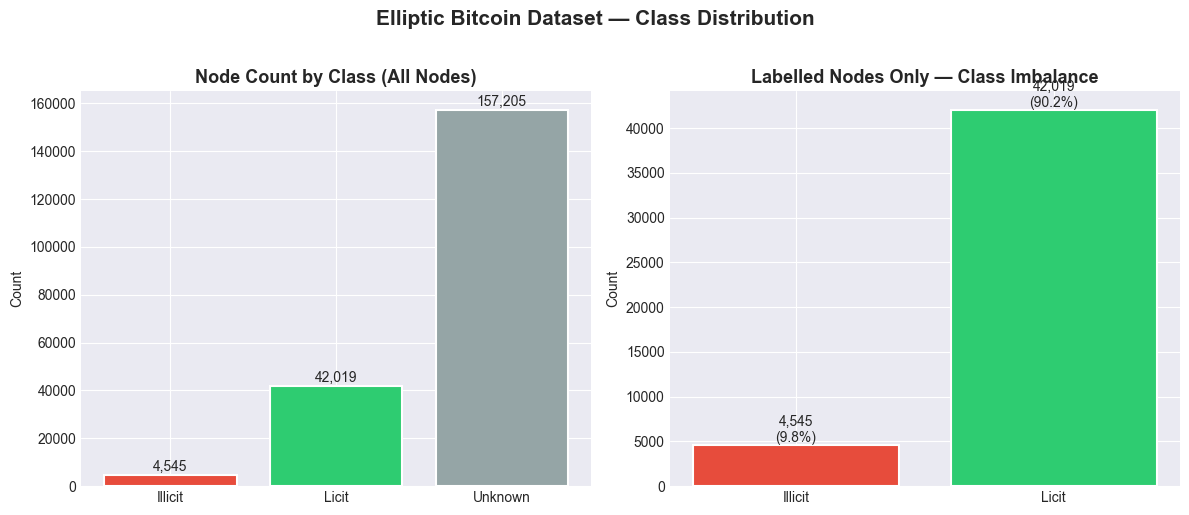

✅ Saved: eda_class_imbalance.png


In [18]:
# ── Plot 1: Class imbalance ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Raw counts (all nodes)
raw_counts = {'Illicit': (labels_arr == 1).sum(),
              'Licit':   (labels_arr == 0).sum(),
              'Unknown': (labels_arr == -1).sum()}
colors = ['#e74c3c', '#2ecc71', '#95a5a6']

ax = axes[0]
bars = ax.bar(raw_counts.keys(), raw_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Node Count by Class (All Nodes)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, raw_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{val:,}',
            ha='center', va='bottom', fontsize=10)

# Labelled only — highlight imbalance
labelled_counts = {'Illicit': (labels_arr == 1).sum(), 'Licit': (labels_arr == 0).sum()}
ax2 = axes[1]
bars2 = ax2.bar(labelled_counts.keys(), labelled_counts.values(), color=colors[:2], edgecolor='white', linewidth=1.5)
total_lab = sum(labelled_counts.values())
for bar, val in zip(bars2, labelled_counts.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}\n({val/total_lab*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax2.set_title('Labelled Nodes Only — Class Imbalance', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count')

plt.suptitle('Elliptic Bitcoin Dataset — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'results', 'eda_class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_class_imbalance.png')

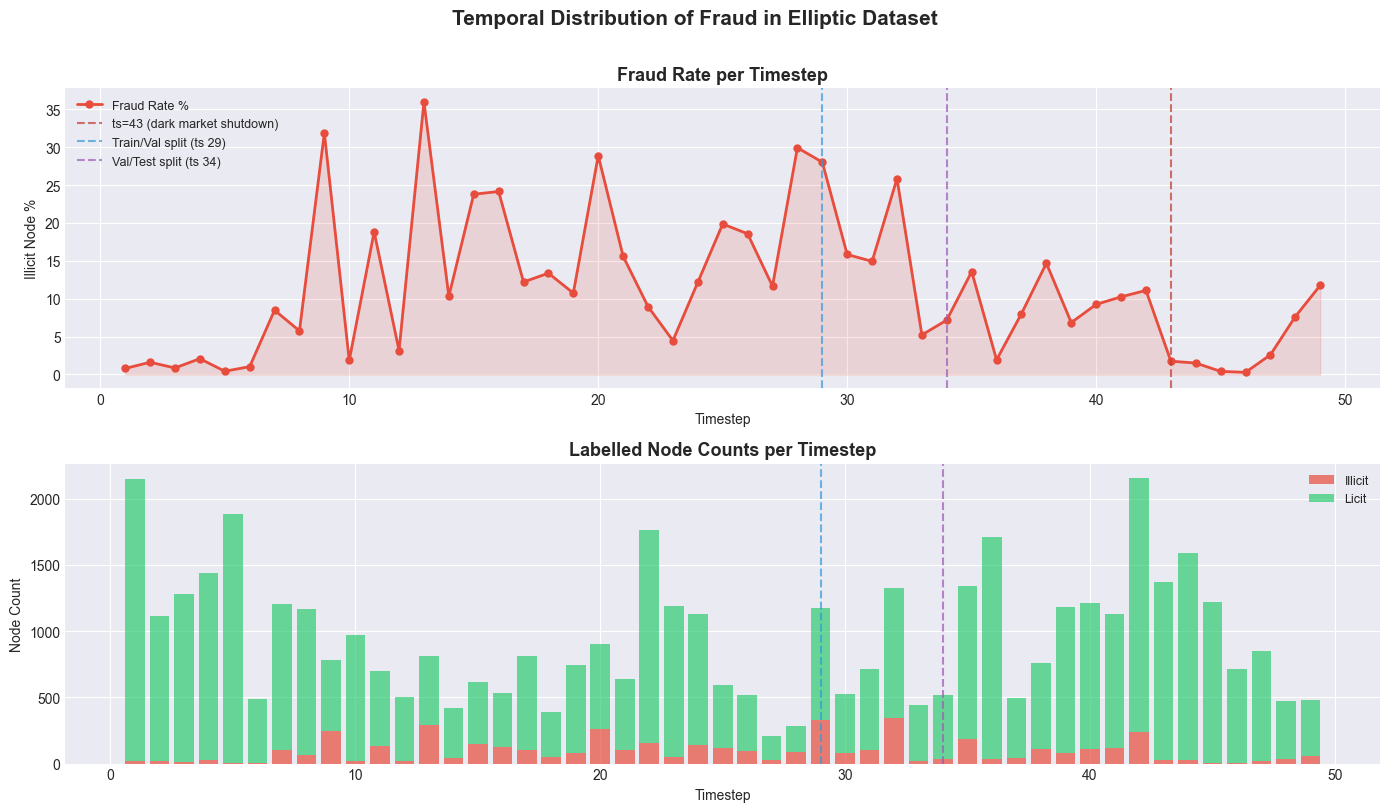

✅ Saved: eda_fraud_per_timestep.png


In [19]:
# ── Plot 2: Fraud rate per timestep ──────────────────────────────────────────
ts_stats = []
for t in range(1, 50):
    mask_t = ts_array == t
    labels_t_step = labels_arr[mask_t]
    known = labels_t_step != -1
    if known.sum() > 0:
        illicit_rate = (labels_t_step[known] == 1).mean()
        n_illicit = (labels_t_step[known] == 1).sum()
        n_known   = known.sum()
    else:
        illicit_rate, n_illicit, n_known = 0, 0, 0
    ts_stats.append({'timestep': t, 'illicit_rate': illicit_rate,
                     'n_illicit': n_illicit, 'n_known': n_known})

ts_df = pd.DataFrame(ts_stats)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Fraud rate
ax = axes[0]
ax.plot(ts_df['timestep'], ts_df['illicit_rate'] * 100, 'o-', color='#e74c3c',
        linewidth=2, markersize=5, label='Fraud Rate %')
ax.fill_between(ts_df['timestep'], ts_df['illicit_rate'] * 100, alpha=0.15, color='#e74c3c')
ax.axvline(x=43, color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.7, label='ts=43 (dark market shutdown)')
ax.axvline(x=TRAIN_TS_END, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Train/Val split (ts {TRAIN_TS_END})')
ax.axvline(x=VAL_TS_END, color='#9b59b6', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Val/Test split (ts {VAL_TS_END})')
ax.set_xlabel('Timestep')
ax.set_ylabel('Illicit Node %')
ax.set_title('Fraud Rate per Timestep', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Absolute counts
ax2 = axes[1]
ax2.bar(ts_df['timestep'], ts_df['n_illicit'], color='#e74c3c', alpha=0.7, label='Illicit')
ax2.bar(ts_df['timestep'], ts_df['n_known'] - ts_df['n_illicit'],
        bottom=ts_df['n_illicit'], color='#2ecc71', alpha=0.7, label='Licit')
ax2.axvline(x=TRAIN_TS_END, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(x=VAL_TS_END, color='#9b59b6', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Node Count')
ax2.set_title('Labelled Node Counts per Timestep', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Temporal Distribution of Fraud in Elliptic Dataset', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'results', 'eda_fraud_per_timestep.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_fraud_per_timestep.png')

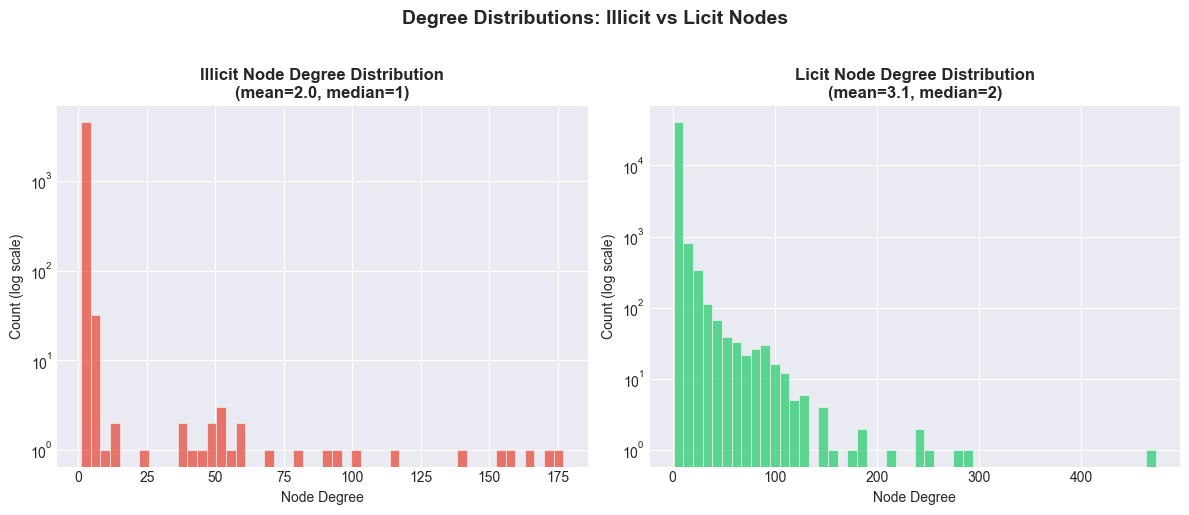

✅ Saved: eda_degree_distribution.png


In [20]:
# ── Plot 3: Degree distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

illicit_mask = labels_arr == 1
licit_mask   = labels_arr == 0

for ax, label_mask, label_name, color in [
    (axes[0], illicit_mask, 'Illicit', '#e74c3c'),
    (axes[1], licit_mask,   'Licit',   '#2ecc71'),
]:
    deg = degrees[label_mask]
    ax.hist(deg, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.set_yscale('log')
    ax.set_xlabel('Node Degree')
    ax.set_ylabel('Count (log scale)')
    ax.set_title(f'{label_name} Node Degree Distribution\n(mean={deg.mean():.1f}, median={np.median(deg):.0f})',
                 fontsize=12, fontweight='bold')

plt.suptitle('Degree Distributions: Illicit vs Licit Nodes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'results', 'eda_degree_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_degree_distribution.png')

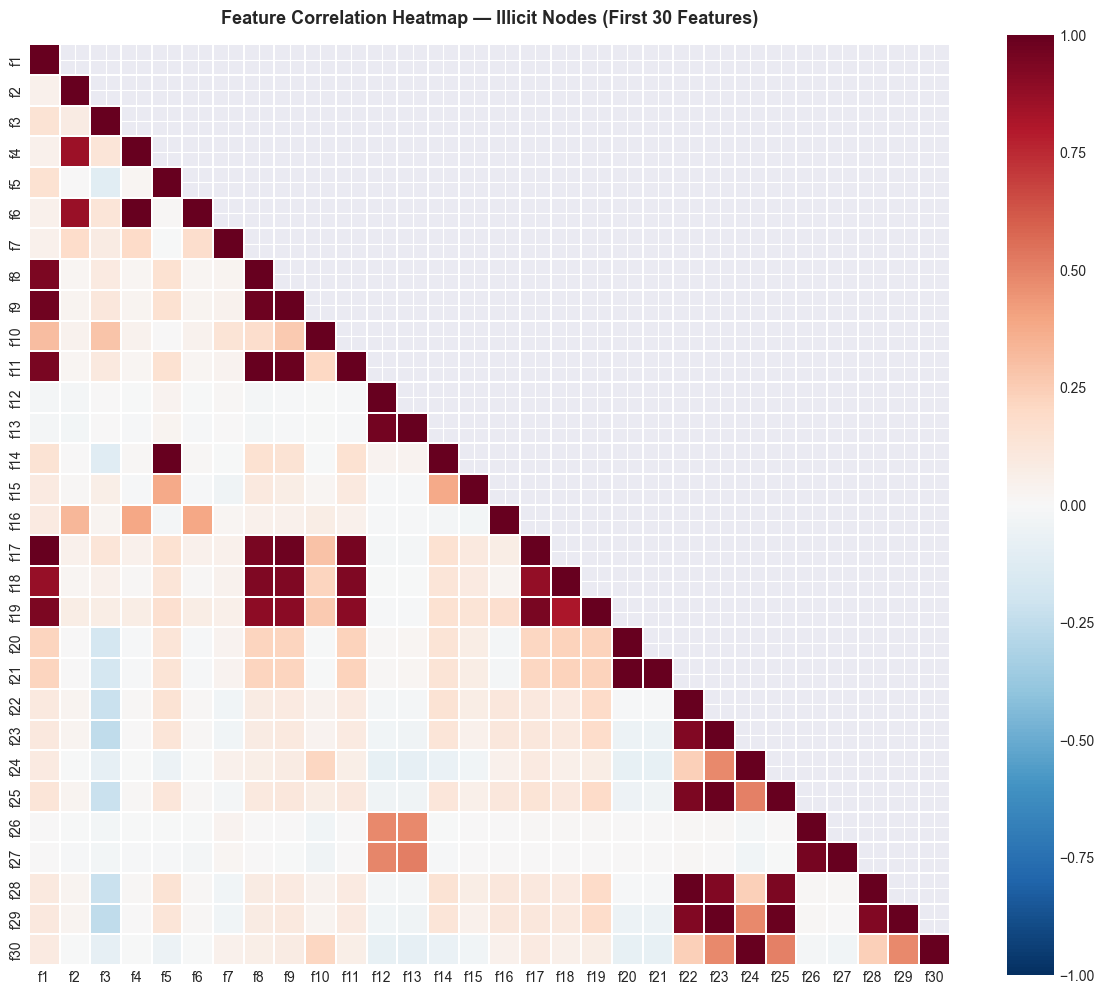

✅ Saved: eda_feature_correlation.png


In [21]:
# ── Plot 4: Feature correlation heatmap (first 30 features, illicit nodes) ──
illicit_feats = normalised[illicit_mask][:, :30]  # first 30 features
corr_matrix = np.corrcoef(illicit_feats.T)

fig, ax = plt.subplots(figsize=(12, 10))
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, ax=ax, mask=mask_upper,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    xticklabels=[f'f{i}' for i in range(1, 31)],
    yticklabels=[f'f{i}' for i in range(1, 31)],
)
ax.set_title('Feature Correlation Heatmap — Illicit Nodes (First 30 Features)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'results', 'eda_feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_feature_correlation.png')

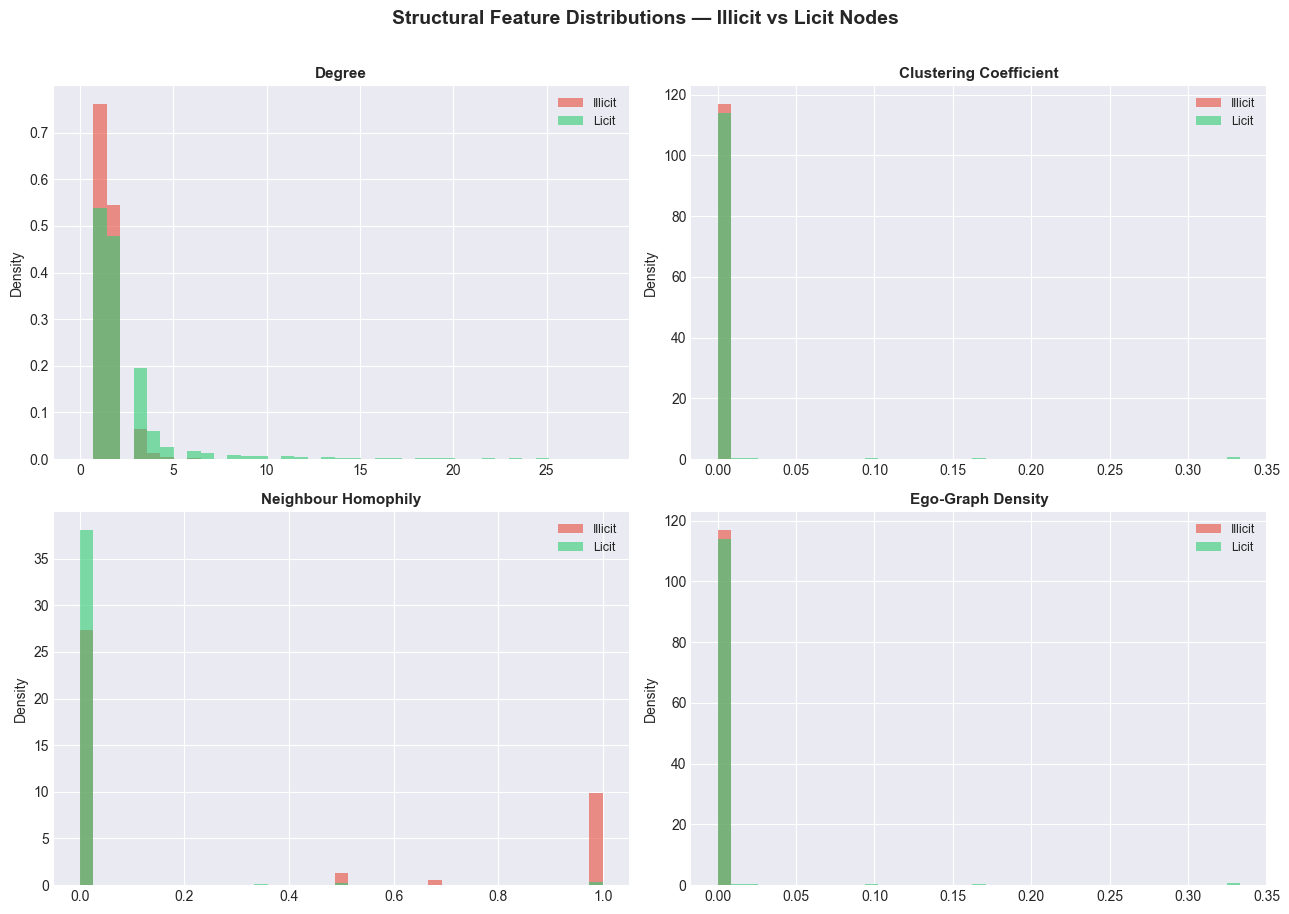

✅ Saved: eda_structural_features.png


In [22]:
# ── Plot 5: Structural feature distributions (Illicit vs Licit) ──────────────
struct_names = ['Degree', 'Clustering Coefficient', 'Neighbour Homophily', 'Ego-Graph Density']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, struct_names)):
    illicit_vals = struct_feats[illicit_mask, i]
    licit_vals   = struct_feats[licit_mask, i]

    # Clip for visibility
    p99_illicit = np.percentile(illicit_vals, 99)
    p99_licit   = np.percentile(licit_vals, 99)
    clip_val    = max(p99_illicit, p99_licit)
    illicit_clipped = illicit_vals[illicit_vals <= clip_val]
    licit_clipped   = licit_vals[licit_vals <= clip_val]

    bins = np.linspace(0, clip_val, 40)
    ax.hist(illicit_clipped, bins=bins, alpha=0.6, color='#e74c3c', label='Illicit', density=True)
    ax.hist(licit_clipped,   bins=bins, alpha=0.6, color='#2ecc71', label='Licit',   density=True)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Structural Feature Distributions — Illicit vs Licit Nodes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'results', 'eda_structural_features.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_structural_features.png')

In [23]:
# ── Summary report ───────────────────────────────────────────────────────────
print('=' * 60)
print('PREPROCESSING COMPLETE — SUMMARY REPORT')
print('=' * 60)
print(f'Total nodes          : {N:,}')
print(f'Total edges          : {len(src_ids):,}')
print(f'Illicit nodes        : {(labels_arr==1).sum():,}  ({(labels_arr==1).mean()*100:.2f}%)')
print(f'Licit nodes          : {(labels_arr==0).sum():,}  ({(labels_arr==0).mean()*100:.2f}%)')
print(f'Unknown nodes        : {(labels_arr==-1).sum():,}  ({(labels_arr==-1).mean()*100:.2f}%)')
print(f'Timestep range       : 1 – 49')
print(f'Feature dim          : 166 (normalised per timestep)')
print(f'Structural feat dim  : 4')
print(f'Train range          : ts 1–{TRAIN_TS_END}')
print(f'Val range            : ts {TRAIN_TS_END+1}–{VAL_TS_END}')
print(f'Test range           : ts {VAL_TS_END+1}–49')
print(f'Temporal violations  : {violations:,}  (edges where src_t > dst_t)')
print('=' * 60)
print(f'All tensors saved to : {PROC_DIR}')
print(f'EDA plots saved to   : {os.path.join(BASE_DIR, "results")}')

PREPROCESSING COMPLETE — SUMMARY REPORT
Total nodes          : 203,769
Total edges          : 234,355
Illicit nodes        : 4,545  (2.23%)
Licit nodes          : 42,019  (20.62%)
Unknown nodes        : 157,205  (77.15%)
Timestep range       : 1 – 49
Feature dim          : 166 (normalised per timestep)
Structural feat dim  : 4
Train range          : ts 1–29
Val range            : ts 30–34
Test range           : ts 35–49
Temporal violations  : 0  (edges where src_t > dst_t)
All tensors saved to : C:\Users\HP\Desktop\project1\graphguard\data\processed
EDA plots saved to   : C:\Users\HP\Desktop\project1\graphguard\results
